In [14]:
from datasets import load_dataset
import numpy as np
import sys
import os
import tiktoken
import matplotlib.pyplot as plt
import seaborn as sns

dataset = load_dataset("dennlinger/eur-lex-sum", "english")
tokenizer = tiktoken.encoding_for_model("gpt-3.5")

In [21]:
test_data = dataset["test"]
lengths = []
for reference in test_data["reference"]:
    lengths.append(len(tokenizer.encode(reference)))

lengths = np.asarray(lengths)

Text(24802.882978723403, 56, '21863.706')

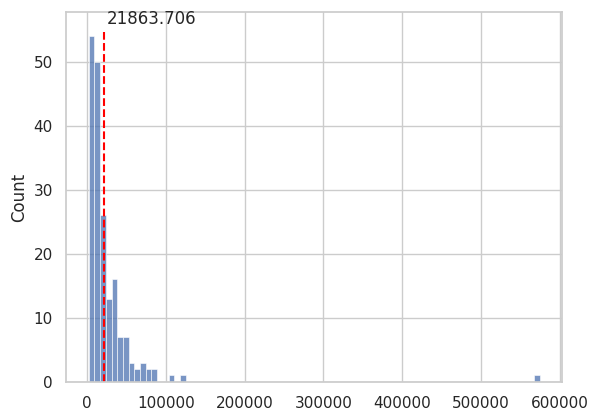

In [35]:

sns.set_theme(style="whitegrid")
sns.histplot(lengths)
# mean without outlier
plt.vlines(x=[np.mean(lengths[lengths < 200000])], ymin=0, ymax=55, linestyles="dashed", color="red")
plt.text(s=f"{np.mean(lengths[lengths < 200000]):0.3f}", x=np.mean(lengths), y=56)

In [38]:
len(lengths[lengths < 32768])/len(test_data) # smaller than Mixtral context size

0.7819148936170213

In [39]:
len(lengths[lengths < 16384])/len(test_data) # smaller than GPT context size

0.5531914893617021

In [40]:
len(lengths[lengths < 8192])/len(test_data) # smaller than Gemma context size

0.2393617021276596

In [41]:
len(lengths[(lengths > 8192) & (lengths < 32768)])/len(test_data) # between context size of Gemma and Mixtral


0.5478723404255319

In [46]:
test_data = dataset["test"]
lengths_sum = []
for reference in test_data["summary"]:
    lengths_sum.append(len(tokenizer.encode(reference)))

lengths_sum = np.asarray(lengths_sum)

Text(610.5, 35, '1260.500')

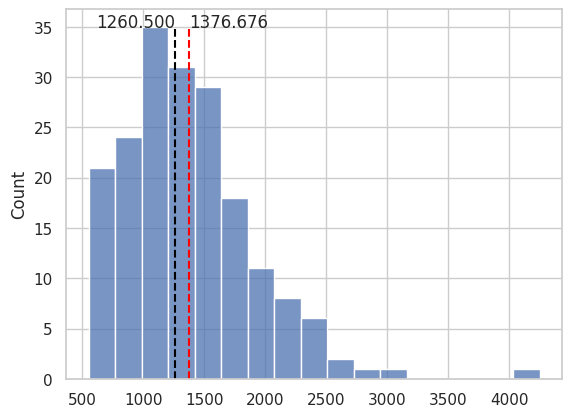

In [58]:
sns.histplot(lengths_sum)
# mean without outlier
plt.vlines(x=[np.mean(lengths_sum)], ymin=0, ymax=35, linestyles="dashed", color="red")
plt.vlines(x=[np.median(lengths_sum)], ymin=0, ymax=35, linestyles="dashed", color="black")
plt.text(s=f"{np.mean(lengths_sum):0.3f}", x=np.mean(lengths_sum), y=35)
plt.text(s=f"{np.median(lengths_sum):0.3f}", x=np.median(lengths_sum)-650, y=35)